In [1]:
# /home/admin/LLM/LLM/01/web/notebooks/analysis.ipynb

import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

# Single imports per library
from src.visualizer import RAGVisualizer
import pandas as pd

# Initialize once
viz = RAGVisualizer()
df = viz.load_selected_experiments(viz.get_experiment_registry()['filename'].tolist())

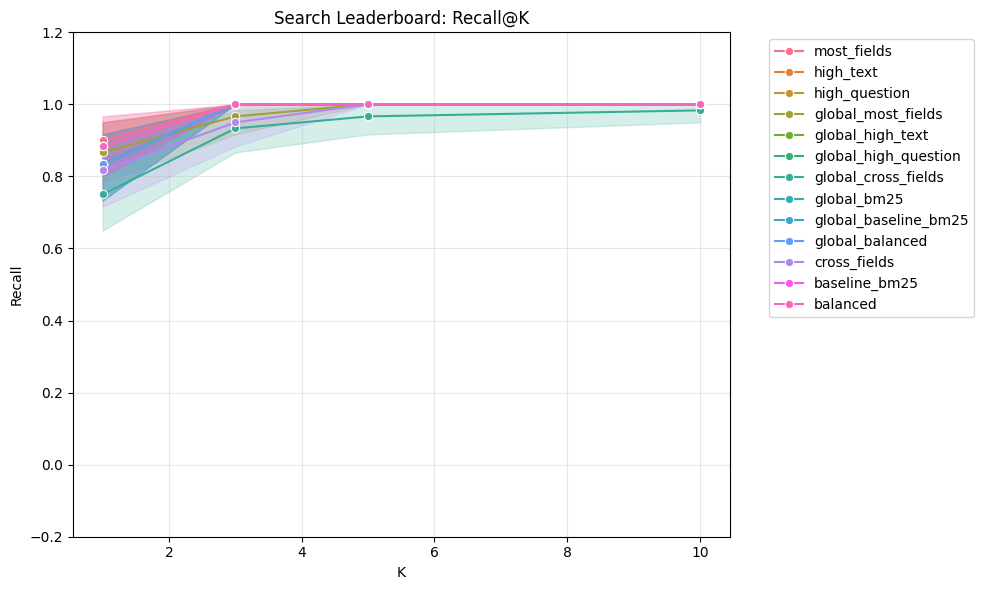

,recall@5,mrr,precision@5,hit_rate@5,unique_courses@5,entropy@5,p95_latency_ms
run_label,,,,,,,
balanced,1.0000,1.0,1.0000,1.0000,3,1.5850,2.5790
baseline_bm25,1.0000,1.0,1.0000,1.0000,3,1.5850,3.1125
cross_fields,1.0000,1.0,1.0000,1.0000,3,1.5850,2.5930
global_balanced,1.0000,1.0,1.0000,1.0000,3,1.5838,2.7565
global_baseline_bm25,1.0000,1.0,1.0000,1.0000,3,1.5838,2.9870
global_bm25,1.0000,1.0,1.0000,1.0000,3,1.5838,2.7510
global_cross_fields,0.9667,1.0,0.9667,0.9667,3,1.5763,2.6820
global_high_question,1.0000,1.0,1.0000,1.0000,3,1.5838,3.0340
global_high_text,1.0000,1.0,1.0000,1.0000,3,1.5838,2.6115


expected_course,data-engineering-zoomcamp,machine-learning-zoomcamp,mlops-zoomcamp
run_label,,,
balanced,1.00,1.00,1.0
baseline_bm25,1.00,1.00,1.0
cross_fields,1.00,1.00,1.0
global_balanced,1.00,1.00,1.0
global_baseline_bm25,1.00,1.00,1.0
global_bm25,1.00,1.00,1.0
global_cross_fields,0.95,0.95,1.0
global_high_question,1.00,1.00,1.0
global_high_text,1.00,1.00,1.0


run_label
global_cross_fields     0.083333
global_balanced         0.050000
global_high_question    0.050000
global_bm25             0.050000
global_baseline_bm25    0.050000
global_most_fields      0.050000
global_high_text        0.050000
balanced                0.000000
cross_fields            0.000000
baseline_bm25           0.000000
high_question           0.000000
high_text               0.000000
most_fields             0.000000
dtype: float64

run_label
balanced                1.000000
baseline_bm25           1.000000
cross_fields            1.000000
global_balanced         1.000000
global_baseline_bm25    1.000000
global_bm25             1.000000
global_high_question    1.000000
global_high_text        1.000000
global_most_fields      1.000000
high_text               1.000000
high_question           1.000000
most_fields             1.000000
global_cross_fields     0.966667
Name: success, dtype: float64

k,1,3,5,10
run_label,,,,
balanced,1.987833,2.306667,1.956667,2.183000
baseline_bm25,2.162167,2.245167,2.220000,2.088167
cross_fields,2.079500,2.070833,2.104500,2.127500
global_balanced,2.147167,2.041833,2.147500,2.136833
global_baseline_bm25,1.843167,1.831500,2.410500,2.609000
global_bm25,1.881167,2.286333,2.183667,1.966167
global_cross_fields,2.015000,1.866167,2.145167,2.650167
global_high_question,2.013833,2.141333,2.075667,2.049000
global_high_text,1.910500,1.954333,1.934833,2.350667


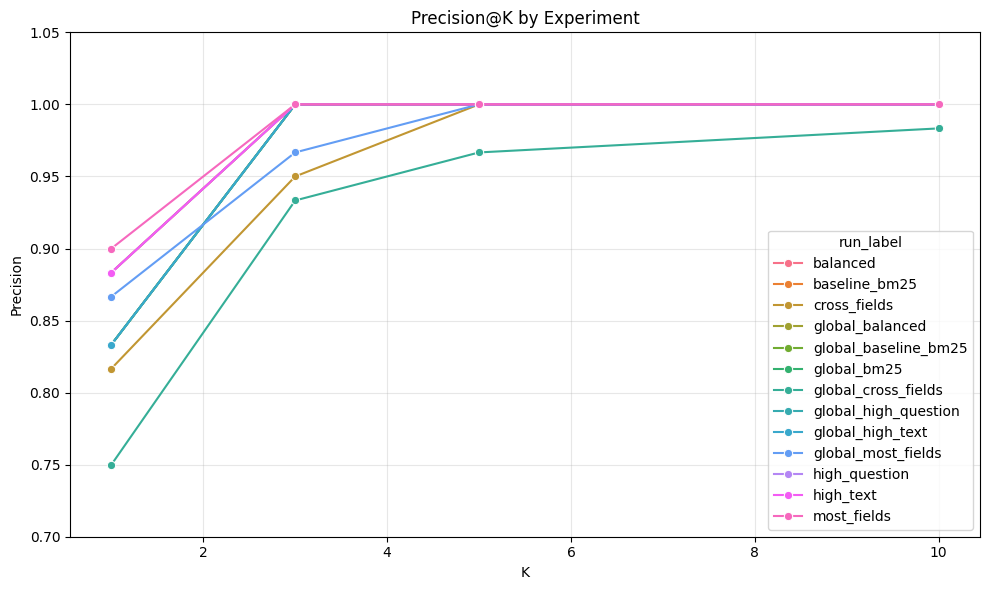

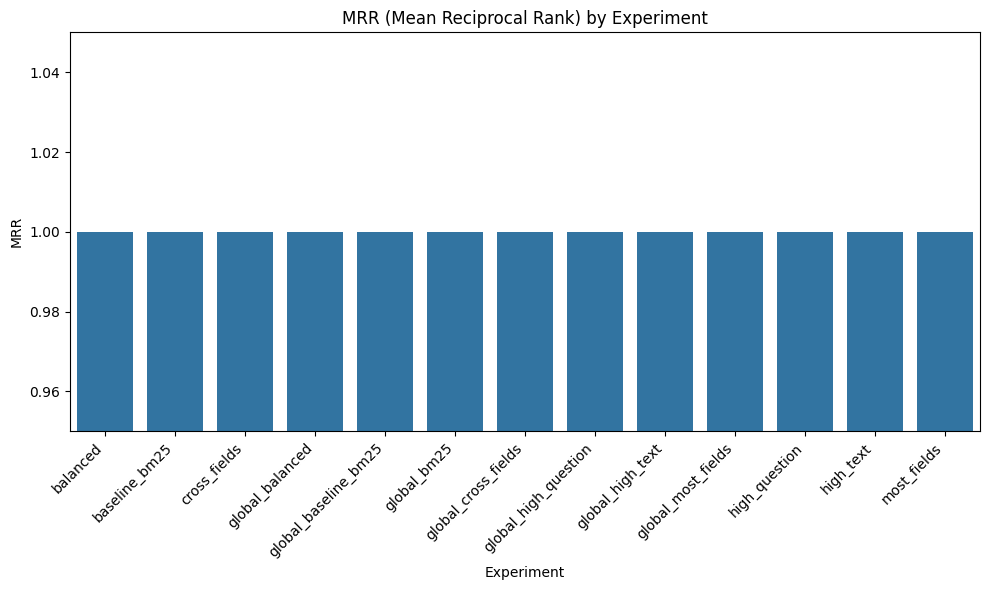

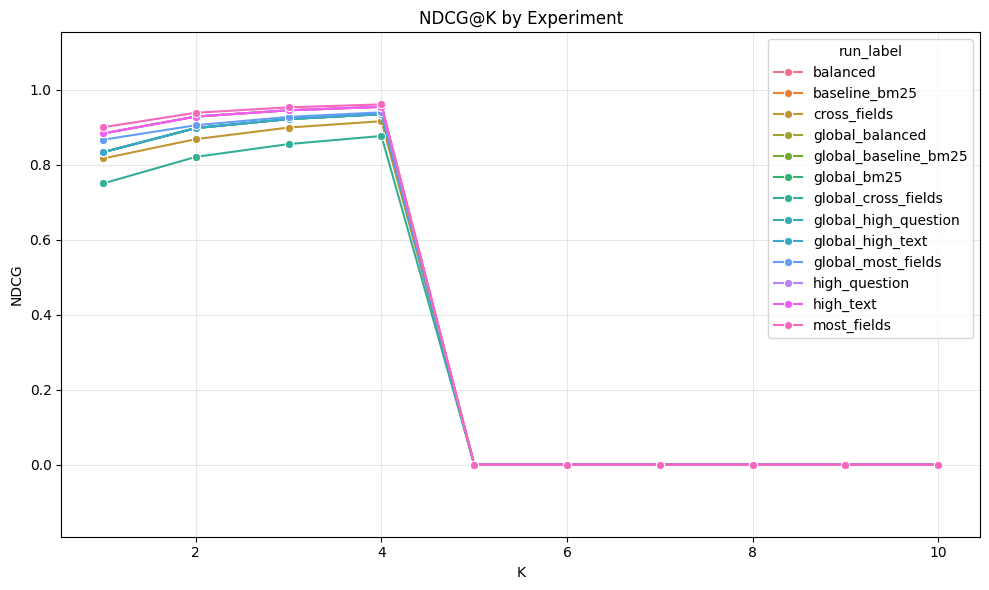

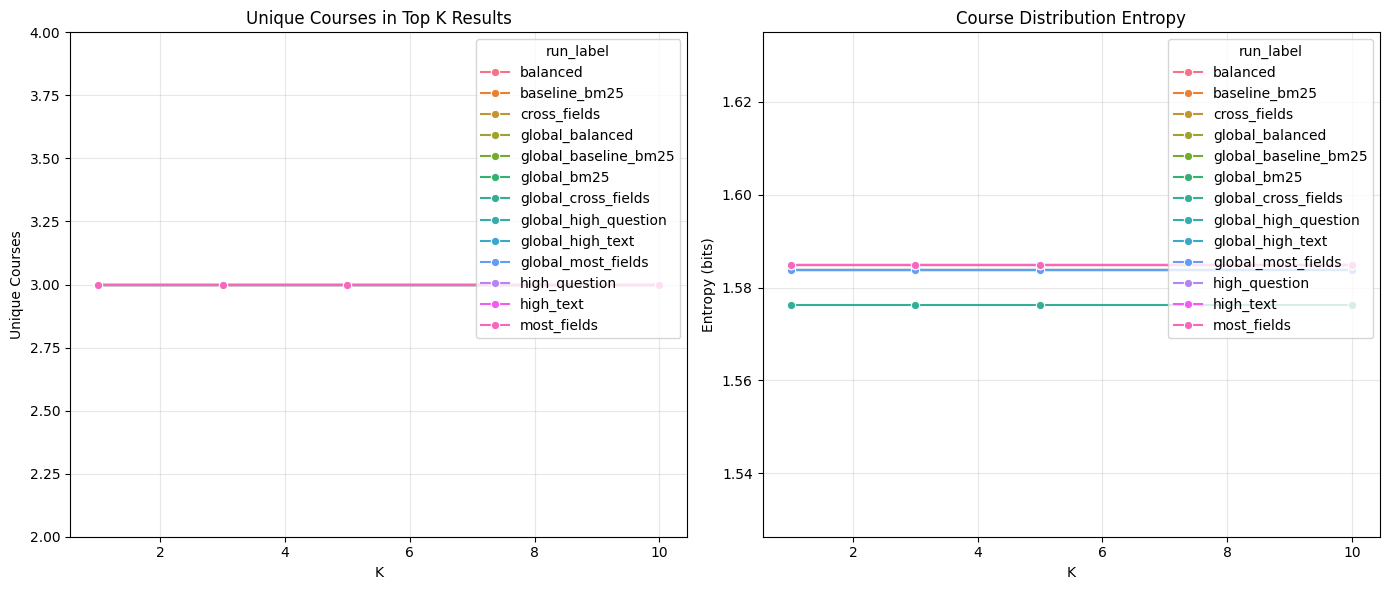

In [2]:
# 1. Leaderboard (Recall@K)
viz.plot_leaderboard(df)

# 2. Comprehensive summary
summary = viz.get_comprehensive_summary(df)
display(summary)

# 3. Recall by course at K=5
recall_by_course = df[df['k'] == 5].groupby(['run_label', 'expected_course'])['success'].mean().unstack()
display(recall_by_course)

# 4. Cross-course rate
cross_rate = (df[df['k'] == 5].groupby('run_label').apply(
    lambda g: (g['expected_course'] != g['found_course']).mean()
))
display(cross_rate.sort_values(ascending=False))

# 5. Best configs by recall@5
best = df[df['k'] == 5].groupby('run_label')['success'].mean().sort_values(ascending=False)
display(best)

# 6. Latency comparison
latency = df.groupby(['run_label', 'k'])['latency_ms'].mean().unstack()
display(latency)

# 7. Precision@K
precision = viz.compute_precision_at_k(df)
viz.plot_precision_at_k(precision)

# 8. MRR comparison
mrr = viz.compute_mrr(df)
viz.plot_mrr_comparison(mrr)

# 9. NDCG comparison
ndcg = viz.compute_ndcg(df)
viz.plot_ndcg_comparison(ndcg)

# 10. Diversity metrics
unique = viz.compute_unique_courses_in_top_k(df)
entropy = viz.compute_course_entropy(df)
viz.plot_diversity_metrics(unique, entropy)

In [3]:
import sys
sys.path.insert(0, '/home/admin/LLM/LLM/01/web')

from src.visualizer import RAGVisualizer
import pandas as pd

viz = RAGVisualizer()
registry = viz.get_experiment_registry()
filenames = registry['filename'].tolist()
df = viz.load_selected_experiments(filenames)
print("=" * 60)
print("SEARCH EVALUATION RESULTS")
print("=" * 60)

# 1. Best configs by recall@5
best = df[df['k'] == 5].groupby('run_label')['success'].mean().sort_values(ascending=False)
print("\n=== BEST CONFIGS BY RECALL@5 ===")
print(best.round(4).to_string())

# 2. Recall by course at K=5
recall_by_course = df[df['k'] == 5].groupby(['run_label', 'expected_course'])['success'].mean().unstack()
print("\n=== RECALL@5 BY COURSE ===")
print(recall_by_course.round(4).to_string())

# 3. Cross-course rate
df['is_cross'] = df['expected_course'] != df['found_course']
cross_rate = df[df['k'] == 5].groupby('run_label')['is_cross'].mean().sort_values(ascending=False)
print("\n=== CROSS-COURSE RATE (K=5) ===")
print(cross_rate.round(4).to_string())

# 4. Average latency by config
latency = df[df['k'] == 5].groupby('run_label')['latency_ms'].mean().sort_values()
print("\n=== AVG LATENCY (ms) at K=5 ===")
print(latency.round(2).to_string())

# 5. Best global config (no filter)
global_configs = [c for c in best.index if c.startswith('global_')]
global_best = best[global_configs]
print("\n=== BEST GLOBAL CONFIGS (No course filter) ===")
print(global_best.round(4).to_string())

# 6. Raw data sample for verification
print("\n=== SAMPLE RESULTS (First 5 DE queries) ===")
de_sample = df[(df['k'] == 5) & (df['expected_course'] == 'data-engineering-zoomcamp')].head(5)
print(de_sample[['query', 'found_course', 'success', 'score']].to_string())

# 7. Summary table
print("\n=== COMPREHENSIVE SUMMARY ===")
summary = viz.get_comprehensive_summary(df)
print(summary.round(4).to_string())

SEARCH EVALUATION RESULTS

=== BEST CONFIGS BY RECALL@5 ===
run_label
balanced                1.0000
baseline_bm25           1.0000
cross_fields            1.0000
global_balanced         1.0000
global_baseline_bm25    1.0000
global_bm25             1.0000
global_high_question    1.0000
global_high_text        1.0000
global_most_fields      1.0000
high_text               1.0000
high_question           1.0000
most_fields             1.0000
global_cross_fields     0.9667

=== RECALL@5 BY COURSE ===
expected_course       data-engineering-zoomcamp  machine-learning-zoomcamp  mlops-zoomcamp
run_label                                                                                 
balanced                                   1.00                       1.00             1.0
baseline_bm25                              1.00                       1.00             1.0
cross_fields                               1.00                       1.00             1.0
global_balanced                            1

In [4]:
from notebooks.ab_test import run_ab_test

df = run_ab_test("baseline_bm25", "global_cross_fields", num_queries=10)

2026-05-04 14:06:51,171 [INFO] - GET http://localhost:9200/ [status:200 request:0.003s]
2026-05-04 14:06:51,173 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 14:06:51,176 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 14:06:51,177 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 14:06:51,180 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,180 [INFO] - Function 'search_faq' executed in 0.0024s


2026-05-04 14:06:51,183 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,183 [INFO] - Function 'search_faq' executed in 0.0026s


2026-05-04 14:06:51,186 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]


...


🔍 [DEBUG] Query: 'What is the expected duration ...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'mlops-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,230 [INFO] - Function 'search_faq' executed in 0.0030s


2026-05-04 14:06:51,233 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



🔍 [DEBUG] Query: 'What’s the difference between ...' | Context: None
📊 [DEBUG] Diversity: {'mlops-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,234 [INFO] - Function 'search_faq' executed in 0.0031s


2026-05-04 14:06:51,236 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



🔍 [DEBUG] Query: 'What’s the difference between ...' | Context: None
📊 [DEBUG] Diversity: {'mlops-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,237 [INFO] - Function 'search_faq' executed in 0.0028s
A/B TEST: baseline_bm25 vs global_cross_fields

Q: When will the course start?
Expected: data-engineering-zoomcamp
[A] baseline_bm25: data-engineering-zoomcamp (score: 10.64)
    When will the course start?...
[B] global_cross_fields: data-engineering-zoomcamp (score: 11.49)
    When will the course start?...
----------------------------------------

Q: What are the prerequisites for this course?
Expected: data-engineering-zoomcamp
[A] baseline_bm25: data-engineering-zoomcamp (score: 13.33)
    What are the prerequisites for this course?...
[B] global_cross_fields: data-engineering-zoomcamp (score: 14.15)
    What are the prerequisites for this course?...
----------------------------------------

Q: Can I still join the course after the start date?
Expected: data-engineering-

In [5]:
from src.experiment_pipeline import compare_configs

results, summary = compare_configs("baseline_bm25", "global_cross_fields", num_queries=20)
print(f"Winner: {summary['winner']}")
print(f"Config A wins: {summary['config_a_wins']}")
print(f"Config B wins: {summary['config_b_wins']}")
print(f"Ties: {summary['ties']}")

2026-05-04 14:06:51,316 [INFO] - GET http://localhost:9200/ [status:200 request:0.002s]
2026-05-04 14:06:51,319 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 14:06:51,322 [INFO] - GET http://localhost:9200/ [status:200 request:0.003s]
2026-05-04 14:06:51,324 [INFO] - HEAD http://localhost:9200/ [status:200 request:0.001s]
2026-05-04 14:06:51,327 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,328 [INFO] - Function 'search_faq' executed in 0.0037s


2026-05-04 14:06:51,332 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



🔍 [DEBUG] Query: 'When will the course start?...' | Context: None
📊 [DEBUG] Diversity: {'data-engineering-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,332 [INFO] - Function 'search_faq' executed in 0.0033s


2026-05-04 14:06:51,335 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]


...


🔍 [DEBUG] Query: 'What if my answer is not exact...' | Context: None
📊 [DEBUG] Diversity: {'mlops-zoomcamp'}
2026-05-04 14:06:51,451 [INFO] - Function 'search_faq' executed in 0.0037s


2026-05-04 14:06:51,454 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.002s]



🔍 [DEBUG] Query: 'Are we free to choose our own ...' | Context: None
📊 [DEBUG] Diversity: {'mlops-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,455 [INFO] - Function 'search_faq' executed in 0.0029s


2026-05-04 14:06:51,459 [INFO] - POST http://localhost:9200/course-questions/_search [status:200 request:0.003s]



🔍 [DEBUG] Query: 'Are we free to choose our own ...' | Context: None
📊 [DEBUG] Diversity: {'mlops-zoomcamp', 'machine-learning-zoomcamp'}
2026-05-04 14:06:51,460 [INFO] - Function 'search_faq' executed in 0.0041s
Results saved to experiments/ab_results/ab_test__baseline_bm25_vs_global_cross_fields__2026-05-04.json

🏆 WINNER: baseline_bm25
   baseline_bm25: 9 wins
   global_cross_fields: 7 wins
   Ties: 2
Winner: baseline_bm25
Config A wins: 9
Config B wins: 7
Ties: 2
